# Approach 1 — Improved SVM + TF-IDF

All improvements applied on top of the baseline `approach1_svm_tfidf.ipynb`:

| Improvement | Targets |
|---|---|
| Teen code normalization | Better TF-IDF features for informal text |
| Multi-label augmentation | More signal for co-occurring intents |
| Handcrafted features | Message-level signals (length, digits, politeness) |
| Logistic Regression | Calibrated probabilities instead of raw decision scores |
| Per-class threshold tuning | Directly fixes multi-label under-prediction |

**Prerequisite:** Run `data_preparation/data_split.ipynb` and `approach1_svm_tfidf.ipynb` first.

In [1]:
# Requirements for this notebook
# See requirements.txt at the project root for the full list
!pip install scikit-learn scipy numpy pandas matplotlib seaborn joblib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp
from scipy.sparse import hstack, vstack as sp_vstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, hamming_loss, accuracy_score, classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

DATA_DIR = '../final_data'

## 1. Load Pre-split Data

In [3]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            texts.append(item['text'])
            labels.append(item['cats'])
    return texts, labels

train_texts, train_labels = load_jsonl(f'{DATA_DIR}/train.jsonl')
val_texts,   val_labels   = load_jsonl(f'{DATA_DIR}/val.jsonl')
test_texts,  test_labels  = load_jsonl(f'{DATA_DIR}/test.jsonl')

mlb    = joblib.load(f'{DATA_DIR}/mlb.joblib')
y_val  = mlb.transform(val_labels)
y_test = mlb.transform(test_labels)

print(f"Train : {len(train_texts):4d} samples")
print(f"Val   : {len(val_texts):4d} samples")
print(f"Test  : {len(test_texts):4d} samples")
print(f"Labels: {len(mlb.classes_)} classes")

Train : 3605 samples
Val   :  454 samples
Test  :  450 samples
Labels: 32 classes


## 2. Teen Code Normalization

Converts informal abbreviations to standard Vietnamese before TF-IDF, so `k` and `không` map to the same feature.

**English tokens are protected** — brand names (`lego`, `ferrari`, `ship`) are kept as-is.

In [4]:
TEEN_CODE = {
    'k'   : 'không', 'ko'  : 'không', 'kh' : 'không',
    'khum': 'không', 'kum' : 'không',
    'đc'  : 'được',  'dc'  : 'được',
    'vs'  : 'với',
    'b'   : 'bạn',
    'sốp' : 'shop',  'sốc' : 'shop',
    'ck'  : 'chuyển khoản',
    'r'   : 'rồi',   'rui' : 'rồi',
    'nha' : 'nhé',   'nhen': 'nhé',
    'sp'  : 'sản phẩm',
    'mn'  : 'mọi người',
}

def normalize(text):
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # ơiiii → ơii
    tokens = text.split()
    result = []
    for token in tokens:
        # protect ASCII tokens not in TEEN_CODE (brand names, borrowed words)
        if re.match(r'^[a-z0-9\-]+$', token) and token not in TEEN_CODE:
            result.append(token)
        else:
            result.append(TEEN_CODE.get(token, token))
    return ' '.join(result)

# Show before / after examples
examples = [
    'sốp ơi còn hàng k ạ',
    'b có hình ảnh thực tế sp này kh ạ',
    'shop còn hàng con ferrari ko ạ',
    'cho e đặt nha, ck dc kh ạ',
]
for text in examples:
    print(f'Before: {text}')
    print(f'After : {normalize(text)}')
    print()

Before: sốp ơi còn hàng k ạ
After : shop ơi còn hàng không ạ

Before: b có hình ảnh thực tế sp này kh ạ
After : bạn có hình ảnh thực tế sản phẩm này không ạ

Before: shop còn hàng con ferrari ko ạ
After : shop còn hàng con ferrari không ạ

Before: cho e đặt nha, ck dc kh ạ
After : cho e đặt nha, chuyển khoản được không ạ



In [5]:
norm_train = [normalize(t) for t in train_texts]
norm_val   = [normalize(t) for t in val_texts]
norm_test  = [normalize(t) for t in test_texts]

print('Normalization applied to all splits.')

Normalization applied to all splits.


## 3. Multi-label Augmentation

Multi-label samples are a small minority, so the model rarely sees co-occurring intent patterns.
Duplicating them 2× gives the classifiers more signal for those cases.

Augmentation is applied to the **training set only**.

In [6]:
multi_idx    = [i for i, l in enumerate(train_labels) if len(l) > 1]
extra_texts  = [norm_train[i]  for i in multi_idx] * 2
extra_labels = [train_labels[i] for i in multi_idx] * 2

aug_texts  = norm_train + extra_texts
aug_labels = train_labels + extra_labels
y_aug      = mlb.transform(aug_labels)

print(f'Original train samples : {len(norm_train)}')
print(f'Multi-label samples    : {len(multi_idx)}')
print(f'Added copies           : {len(extra_texts)}')
print(f'Augmented train total  : {len(aug_texts)}')

Original train samples : 3605
Multi-label samples    : 387
Added copies           : 774
Augmented train total  : 4379


## 4. Feature Extraction

Three feature groups combined:

| Group | Description |
|---|---|
| Word TF-IDF (1,2)-gram | Word-level and short phrase patterns |
| Char TF-IDF (2,4)-gram | Subword patterns, captures remaining informal tokens |
| Handcrafted features | Message-level signals the vectorizers miss |

In [7]:
def handcrafted_features(texts):
    rows = []
    for t in texts:
        rows.append([
            len(t.split()),                               # word count
            len(t),                                       # char count
            t.count('?'),                                 # question marks
            int(bool(re.search(r'0[3-9]\d{8}', t))),     # phone number
            int(bool(re.search(r'\d+', t))),              # any digit
            int('ạ' in t or 'nhé' in t or 'nha' in t),   # politeness marker
        ])
    return sp.csr_matrix(rows, dtype=np.float32)


tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    max_features=30_000, min_df=2, sublinear_tf=True
)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_features=20_000, min_df=2, sublinear_tf=True
)

# Fit on augmented training set only
X_aug_word = tfidf_word.fit_transform(aug_texts)
X_aug_char = tfidf_char.fit_transform(aug_texts)
X_aug_feat = hstack([X_aug_word, X_aug_char, handcrafted_features(aug_texts)])

X_val_feat  = hstack([tfidf_word.transform(norm_val),  tfidf_char.transform(norm_val),  handcrafted_features(norm_val)])
X_test_feat = hstack([tfidf_word.transform(norm_test), tfidf_char.transform(norm_test), handcrafted_features(norm_test)])

print(f'Feature matrix — augmented train: {X_aug_feat.shape}')

Feature matrix — augmented train: (4379, 15049)


## 5. Train Logistic Regression (OvR)

Logistic Regression is used instead of LinearSVC because it produces **calibrated probabilities** via `predict_proba`, which makes per-class threshold tuning more principled.

In [8]:
best_c, best_val_f1 = None, 0.0

for C in [0.1, 1.0, 10.0]:
    clf = OneVsRestClassifier(
        LogisticRegression(C=C, class_weight='balanced', max_iter=1000, solver='lbfgs'),
        n_jobs=1
    )
    clf.fit(X_aug_feat, y_aug)
    y_pred_val = clf.predict(X_val_feat)

    macro_f1 = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
    micro_f1 = f1_score(y_val, y_pred_val, average='micro', zero_division=0)
    print(f'  C={C:5.1f}  |  Val Macro-F1: {macro_f1:.4f}  |  Val Micro-F1: {micro_f1:.4f}')

    if macro_f1 > best_val_f1:
        best_val_f1, best_c = macro_f1, C

print(f'\nBest C = {best_c}  (Val Macro-F1 = {best_val_f1:.4f})')

  C=  0.1  |  Val Macro-F1: 0.6486  |  Val Micro-F1: 0.6421
  C=  1.0  |  Val Macro-F1: 0.7950  |  Val Micro-F1: 0.7990
  C= 10.0  |  Val Macro-F1: 0.8468  |  Val Micro-F1: 0.8517

Best C = 10.0  (Val Macro-F1 = 0.8468)


## 6. Per-class Threshold Tuning

The default threshold of 0.5 applies equally to all 32 classes. Rare or co-occurring classes need a lower threshold to be predicted at all.

For each class, we search for the threshold `t ∈ [0.1, 0.9]` that maximises F1 on the validation set.

In [9]:
# Train with best C, evaluate on val to find per-class thresholds
tuning_model = OneVsRestClassifier(
    LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, solver='lbfgs'),
    n_jobs=1
)
tuning_model.fit(X_aug_feat, y_aug)
val_proba = tuning_model.predict_proba(X_val_feat)  # shape: (n_val, 32)

thresholds = []
for i, cls in enumerate(mlb.classes_):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.10, 0.95, 0.05):
        preds = (val_proba[:, i] >= t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    thresholds.append(best_t)

df_thresh = pd.DataFrame({'Class': mlb.classes_, 'Threshold': thresholds})
print(df_thresh.to_string(index=False))

                    Class  Threshold
                  Goodbye       0.60
              add_product       0.40
                    agree       0.65
              agree_order       0.55
          ask_final_price       0.90
         ask_find_product       0.45
         ask_gift_package       0.40
                ask_legit       0.85
         ask_order_status       0.65
      ask_order_wait_time       0.80
       ask_payment_method       0.30
 ask_product_availability       0.70
        ask_product_image       0.75
         ask_product_info       0.35
        ask_product_price       0.40
   ask_product_suggestion       0.60
         ask_shipping_fee       0.80
            ask_shop_info       0.40
               buy_thanks       0.85
  complain_shipping_issue       0.60
         confirm_received       0.85
          customer_reject       0.80
delivery_time_requirement       0.45
       get_product_direct       0.75
             give_product       0.40
                 greeting       0.60
 

In [10]:
# Retrain final model on train + val combined
X_val_for_merge = hstack([
    tfidf_word.transform(norm_val),
    tfidf_char.transform(norm_val),
    handcrafted_features(norm_val)
])
X_trainval = sp_vstack([X_aug_feat, X_val_for_merge])
y_trainval  = np.vstack([y_aug, y_val])

final_model = OneVsRestClassifier(
    LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, solver='lbfgs'),
    n_jobs=1
)
final_model.fit(X_trainval, y_trainval)
print(f'Final model trained on train+val ({len(y_trainval)} samples).')

Final model trained on train+val (4833 samples).


## 7. Evaluate on Test Set

In [11]:
test_proba   = final_model.predict_proba(X_test_feat)
y_pred_tuned = (test_proba >= np.array(thresholds)).astype(int)

macro_f1   = f1_score(y_test, y_pred_tuned, average='macro',  zero_division=0)
micro_f1   = f1_score(y_test, y_pred_tuned, average='micro',  zero_division=0)
h_loss     = hamming_loss(y_test, y_pred_tuned)
subset_acc = accuracy_score(y_test, y_pred_tuned)

print('=' * 50)
print('TEST RESULTS — Approach 1 (Improved)')
print('=' * 50)
print(f'Macro-F1        : {macro_f1:.4f}')
print(f'Micro-F1        : {micro_f1:.4f}')
print(f'Hamming Loss    : {h_loss:.4f}')
print(f'Subset Accuracy : {subset_acc:.4f}')

TEST RESULTS — Approach 1 (Improved)
Macro-F1        : 0.8695
Micro-F1        : 0.8727
Hamming Loss    : 0.0090
Subset Accuracy : 0.7600


In [12]:
print(classification_report(
    y_test, y_pred_tuned,
    target_names=mlb.classes_,
    zero_division=0
))

                           precision    recall  f1-score   support

                  Goodbye       0.91      0.91      0.91        11
              add_product       0.91      0.91      0.91        11
                    agree       0.94      0.85      0.89        20
              agree_order       0.94      0.94      0.94        17
          ask_final_price       1.00      0.50      0.67         6
         ask_find_product       1.00      0.25      0.40         4
         ask_gift_package       0.83      0.83      0.83         6
                ask_legit       1.00      0.90      0.95        10
         ask_order_status       0.96      0.96      0.96        23
      ask_order_wait_time       1.00      0.83      0.91        12
       ask_payment_method       0.89      1.00      0.94        17
 ask_product_availability       0.78      0.81      0.79        26
        ask_product_image       0.92      0.85      0.88        13
         ask_product_info       0.73      0.92      0.81     

## 8. Compare with Baseline

Loads metrics from `approach1_svm_tfidf.ipynb` results and compares side by side.

In [13]:
try:
    with open('results/metrics.json', 'r', encoding='utf-8') as f:
        baseline = json.load(f)
except FileNotFoundError:
    print('Baseline metrics not found. Run approach1_svm_tfidf.ipynb first.')
    baseline = None

if baseline:
    df_cmp = pd.DataFrame({
        'Metric'  : ['Macro-F1', 'Micro-F1', 'Hamming Loss', 'Subset Accuracy'],
        'Baseline': [baseline['macro_f1'], baseline['micro_f1'],
                     baseline['hamming_loss'], baseline['subset_accuracy']],
        'Improved': [round(macro_f1, 4), round(micro_f1, 4),
                     round(h_loss, 4),   round(subset_acc, 4)],
    })
    df_cmp['Delta'] = (df_cmp['Improved'] - df_cmp['Baseline']).apply(
        lambda x: f'+{x:.4f}' if x > 0 else f'{x:.4f}'
    )
    display(df_cmp)

,Metric,Baseline,Improved,Delta
0,Macro-F1,0.8569,0.8695,+0.0126
1,Micro-F1,0.8740,0.8727,-0.0013
2,Hamming Loss,0.0088,0.0090,+0.0002
3,Subset Accuracy,0.7756,0.7600,-0.0156


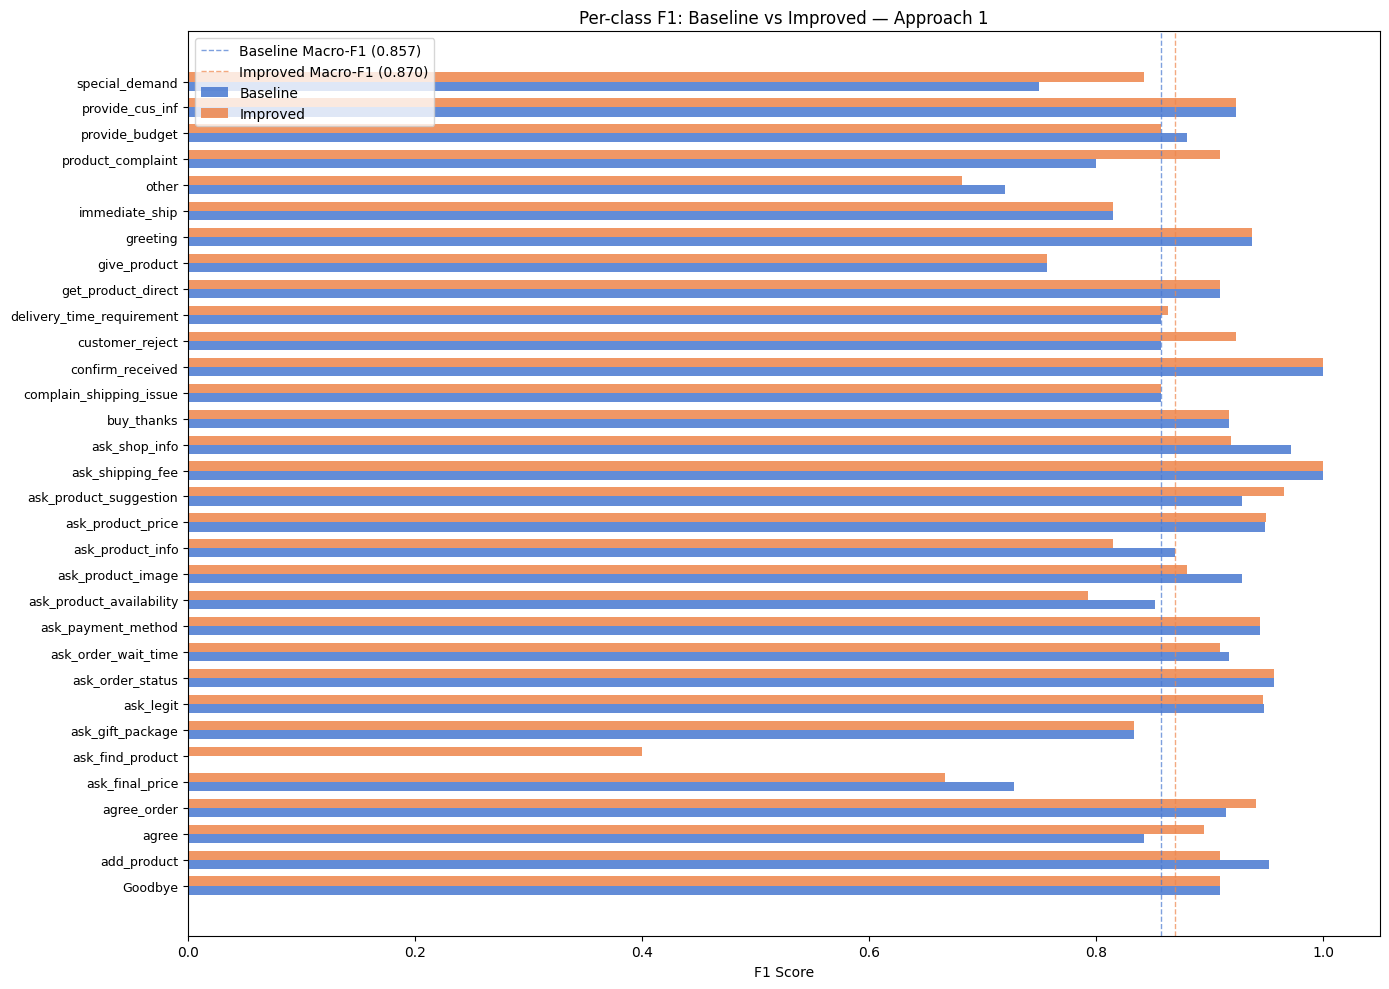

In [14]:
if baseline:
    per_class_f1_improved  = f1_score(y_test, y_pred_tuned, average=None, zero_division=0)
    per_class_f1_baseline  = np.array([baseline['per_class_f1'][c] for c in mlb.classes_])

    x     = np.arange(len(mlb.classes_))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.barh(x - width / 2, per_class_f1_baseline, width, label='Baseline', color='#4878d0', alpha=0.85)
    ax.barh(x + width / 2, per_class_f1_improved, width, label='Improved', color='#ee854a', alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(mlb.classes_, fontsize=9)
    ax.axvline(baseline['macro_f1'], color='#4878d0', linestyle='--', linewidth=1, alpha=0.7,
               label=f'Baseline Macro-F1 ({baseline["macro_f1"]:.3f})')
    ax.axvline(macro_f1, color='#ee854a', linestyle='--', linewidth=1, alpha=0.7,
               label=f'Improved Macro-F1 ({macro_f1:.3f})')
    ax.set_xlabel('F1 Score')
    ax.set_title('Per-class F1: Baseline vs Improved — Approach 1')
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/comparison_per_class_f1.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8b. Learning Curve

Shows how Macro-F1 changes as the model sees more training data — the standard diagnostic for non-neural models, equivalent to a loss curve for neural networks.

| Pattern | Meaning |
|---|---|
| Train F1 >> Val F1 (large gap) | Overfitting — model memorises training data |
| Both curves low and flat | Underfitting — need a better model or features |
| Train ≈ Val F1, both high | Well-fitted — more data gives diminishing returns |

**Note:** Fixed threshold 0.5 is used here (not per-class tuned thresholds) so scores are comparable across training sizes.

     10% ( 437 samples) — Train F1: 0.9908  Val F1: 0.5987
     20% ( 875 samples) — Train F1: 0.9934  Val F1: 0.7352
     30% (1313 samples) — Train F1: 0.9913  Val F1: 0.7809
     40% (1751 samples) — Train F1: 0.9878  Val F1: 0.8066
     50% (2189 samples) — Train F1: 0.9859  Val F1: 0.8295
     60% (2627 samples) — Train F1: 0.9832  Val F1: 0.8449
     70% (3065 samples) — Train F1: 0.9818  Val F1: 0.8432
     80% (3503 samples) — Train F1: 0.9800  Val F1: 0.8419
     90% (3941 samples) — Train F1: 0.9831  Val F1: 0.8488
    100% (4379 samples) — Train F1: 0.9831  Val F1: 0.8468


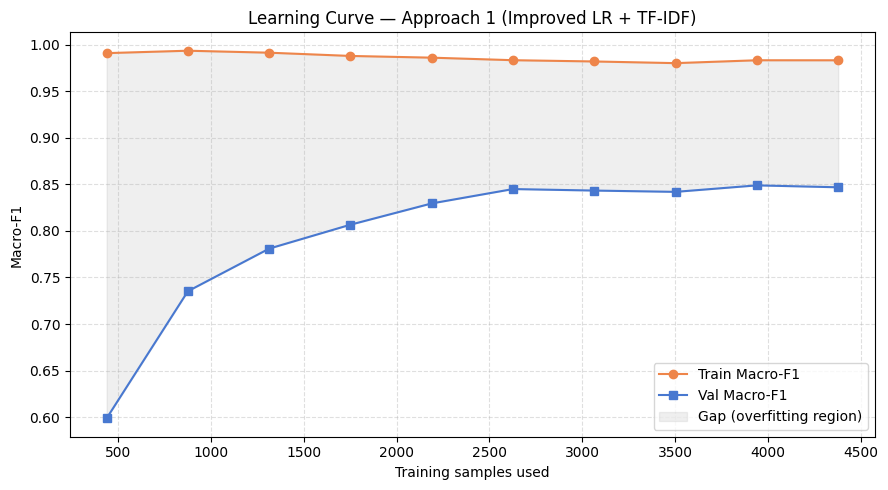


Final gap (Train - Val): +0.1363


In [15]:
fractions   = np.linspace(0.1, 1.0, 10)
train_f1s   = []
val_f1s     = []
train_sizes = []

n_total = X_aug_feat.shape[0]

for frac in fractions:
    n = max(1, int(n_total * frac))
    X_sub = X_aug_feat[:n]
    y_sub = y_aug[:n]

    clf = OneVsRestClassifier(
        LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, solver='lbfgs'),
        n_jobs=1
    )
    clf.fit(X_sub, y_sub)

    train_pred = clf.predict(X_sub)
    val_pred   = clf.predict(X_val_feat)

    train_f1s.append(f1_score(y_sub,  train_pred, average='macro', zero_division=0))
    val_f1s.append(  f1_score(y_val,  val_pred,   average='macro', zero_division=0))
    train_sizes.append(n)
    print(f'  {frac*100:5.0f}% ({n:4d} samples) — Train F1: {train_f1s[-1]:.4f}  Val F1: {val_f1s[-1]:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_f1s, 'o-', color='#ee854a', label='Train Macro-F1')
ax.plot(train_sizes, val_f1s,   's-', color='#4878d0', label='Val Macro-F1')
ax.fill_between(train_sizes, train_f1s, val_f1s,
                alpha=0.12, color='gray', label='Gap (overfitting region)')
ax.set_xlabel('Training samples used')
ax.set_ylabel('Macro-F1')
ax.set_title('Learning Curve — Approach 1 (Improved LR + TF-IDF)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFinal gap (Train - Val): {train_f1s[-1] - val_f1s[-1]:+.4f}')

## 9. Save Model and Results

In [16]:
joblib.dump(final_model, 'results/svm_improved_model.joblib')
joblib.dump(tfidf_word,  'results/svm_improved_tfidf_word.joblib')
joblib.dump(tfidf_char,  'results/svm_improved_tfidf_char.joblib')

per_class_f1_improved = f1_score(y_test, y_pred_tuned, average=None, zero_division=0)

metrics = {
    'approach'        : 'SVM + TF-IDF (Improved)',
    'best_C'          : best_c,
    'thresholds'      : {k: round(float(v), 4) for k, v in zip(mlb.classes_, thresholds)},
    'macro_f1'        : round(macro_f1,   4),
    'micro_f1'        : round(micro_f1,   4),
    'hamming_loss'    : round(h_loss,     4),
    'subset_accuracy' : round(subset_acc, 4),
    'per_class_f1'    : {k: round(float(v), 4) for k, v in zip(mlb.classes_, per_class_f1_improved)}
}

with open('results/metrics_improved.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Saved to approach1/results/:')
for fname in ['svm_improved_model.joblib', 'svm_improved_tfidf_word.joblib',
              'svm_improved_tfidf_char.joblib', 'metrics_improved.json',
              'comparison_per_class_f1.png']:
    print(f'  {fname}')

Saved to approach1/results/:
  svm_improved_model.joblib
  svm_improved_tfidf_word.joblib
  svm_improved_tfidf_char.joblib
  metrics_improved.json
  comparison_per_class_f1.png


## 10. Test Custom Input

In [17]:
import joblib, json, re, datetime
import numpy as np
import scipy.sparse as sp
from scipy.sparse import hstack

_model      = joblib.load('results/svm_improved_model.joblib')
_tfidf_word = joblib.load('results/svm_improved_tfidf_word.joblib')
_tfidf_char = joblib.load('results/svm_improved_tfidf_char.joblib')
_mlb        = joblib.load('../final_data/mlb.joblib')

with open('results/metrics_improved.json', encoding='utf-8') as f:
    _thresholds = np.array(list(json.load(f)['thresholds'].values()))

# In-memory log — persists across predict() calls within this session
_prediction_log = []

def predict(text: str, top_k: int = 3):
    norm = normalize(text)
    feat = hstack([
        _tfidf_word.transform([norm]),
        _tfidf_char.transform([norm]),
        handcrafted_features([norm])
    ])
    proba     = _model.predict_proba(feat)[0]
    predicted = tuple(
        cls for cls, p, t in zip(_mlb.classes_, proba, _thresholds) if p >= t
    )
    ranked = sorted(zip(_mlb.classes_, proba), key=lambda x: -x[1])

    # Append to history log
    _prediction_log.append({
        'timestamp' : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input'     : text,
        'normalized': norm,
        'predicted' : list(predicted),
        'top_proba' : {label: round(float(prob), 4) for label, prob in ranked[:top_k]},
    })

    print(f'Input     : {text}')
    print(f'Normalized: {norm}')
    print(f'Predicted : {list(predicted) if predicted else "[none above threshold]"}')
    print(f'Top {top_k} probabilities:')
    for label, prob in ranked[:top_k]:
        marker = ' <--' if label in predicted else ''
        print(f'  {label:<35} {prob:.3f}{marker}')

print('predict() ready.  History log is in _prediction_log.')

predict() ready.  History log is in _prediction_log.


In [18]:
# ── Change this text and re-run ───────────────────────────────────────────────
predict('sốp ơi còn hàng con ferrari k ạ')

Input     : sốp ơi còn hàng con ferrari k ạ
Normalized: shop ơi còn hàng con ferrari không ạ
Predicted : ['ask_product_availability']
Top 3 probabilities:
  ask_product_availability            1.000 <--
  give_product                        0.037
  ask_find_product                    0.025


In [19]:
# Test multiple messages at once
samples = [
    'shop ơi',
    'bao g có hàng thế ạ',
    'cho e đặt màu xanh với ạ',
    'giá con này bao nhiêu vậy shop',
]

for text in samples:
    print('-' * 55)
    predict(text, top_k=2)
print('-' * 55)

-------------------------------------------------------
Input     : shop ơi
Normalized: shop ơi
Predicted : ['greeting']
Top 2 probabilities:
  greeting                            0.998 <--
  agree                               0.056
-------------------------------------------------------
Input     : bao g có hàng thế ạ
Normalized: bao g có hàng thế ạ
Predicted : ['ask_order_wait_time']
Top 2 probabilities:
  ask_order_wait_time                 0.995 <--
  ask_order_status                    0.266
-------------------------------------------------------
Input     : cho e đặt màu xanh với ạ
Normalized: cho e đặt màu xanh với ạ
Predicted : ['agree_order']
Top 2 probabilities:
  agree_order                         0.997 <--
  agree                               0.391
-------------------------------------------------------
Input     : giá con này bao nhiêu vậy shop
Normalized: giá con này bao nhiêu vậy shop
Predicted : ['ask_product_price']
Top 2 probabilities:
  ask_product_price          

## 11. Prediction History Log

Every `predict()` call is recorded in `_prediction_log` (in-memory) and can be:

- **Viewed** as a table with `show_log()`
- **Saved** to `results/prediction_log.jsonl` with `save_log()`
- **Cleared** with `clear_log()`

Each entry records: timestamp, original input, normalized text, predicted intents, and top-k probabilities.

In [20]:
def show_log(n: int = None):
    """Print the prediction history as a table. n=None shows all entries."""
    entries = _prediction_log if n is None else _prediction_log[-n:]
    if not entries:
        print('Log is empty — run predict() first.')
        return
    print(f'{"#":<4} {"Timestamp":<20} {"Input":<40} {"Predicted"}')
    print('-' * 100)
    for i, e in enumerate(_prediction_log):
        idx      = i + 1
        ts       = e['timestamp']
        inp      = e['input'][:38] + '..' if len(e['input']) > 40 else e['input']
        preds    = ', '.join(e['predicted']) if e['predicted'] else '[none]'
        if entries is not _prediction_log:
            idx = len(_prediction_log) - len(entries) + i + 1
        print(f'{idx:<4} {ts:<20} {inp:<40} {preds}')
    print(f'\nTotal entries: {len(_prediction_log)}')

show_log()

#    Timestamp            Input                                    Predicted
----------------------------------------------------------------------------------------------------
1    2026-06-05 23:04:24  sốp ơi còn hàng con ferrari k ạ          ask_product_availability
2    2026-06-05 23:04:24  shop ơi                                  greeting
3    2026-06-05 23:04:24  bao g có hàng thế ạ                      ask_order_wait_time
4    2026-06-05 23:04:24  cho e đặt màu xanh với ạ                 agree_order
5    2026-06-05 23:04:24  giá con này bao nhiêu vậy shop           ask_product_price

Total entries: 5


In [21]:
LOG_PATH = 'results/prediction_log.jsonl'

def save_log(path: str = LOG_PATH, mode: str = 'append'):
    """
    Save _prediction_log to a JSONL file.
    mode='append' adds new entries to the end of an existing file.
    mode='overwrite' replaces the file entirely.
    """
    if not _prediction_log:
        print('Nothing to save — log is empty.')
        return

    if mode == 'append':
        # Load existing entries to avoid duplicates (match by timestamp + input)
        existing_keys = set()
        try:
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    e = json.loads(line)
                    existing_keys.add((e['timestamp'], e['input']))
        except FileNotFoundError:
            pass

        new_entries = [e for e in _prediction_log
                       if (e['timestamp'], e['input']) not in existing_keys]

        with open(path, 'a', encoding='utf-8') as f:
            for e in new_entries:
                json.dump(e, f, ensure_ascii=False)
                f.write('\n')

        print(f'Appended {len(new_entries)} new entries → {path}')

    else:  # overwrite
        with open(path, 'w', encoding='utf-8') as f:
            for e in _prediction_log:
                json.dump(e, f, ensure_ascii=False)
                f.write('\n')
        print(f'Saved {len(_prediction_log)} entries → {path} (overwrite)')


def clear_log():
    """Clear the in-memory log (does NOT delete the saved JSONL file)."""
    count = len(_prediction_log)
    _prediction_log.clear()
    print(f'Cleared {count} entries from in-memory log.')


# ── Usage examples ────────────────────────────────────────────────────────────
# save_log()                     # append new entries to results/prediction_log.jsonl
# save_log(mode='overwrite')     # replace the file
# show_log(n=5)                  # show last 5 entries
# clear_log()                    # wipe in-memory log
print('save_log() / clear_log() ready.')

save_log() / clear_log() ready.
